In [69]:
import os
import json
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [53]:
log_dir = "/home/igor/repos/committee-analysis/simulation-20250827/simulation-20250827-124845-n1000-m8-d5-c100"

In [54]:
import json, re

_UNIT = {"ns": 1e-9, "us": 1e-6, "µs": 1e-6, "ms": 1e-3, "s": 1.0, "m": 60.0, "h": 3600.0}
_TOKEN_RE = re.compile(r'(\d+(?:\.\d+)?)(ns|µs|us|ms|s|m|h)')

def parse_go_duration_to_seconds(s: str) -> float:
    """
    Parse a Go time.Duration string (e.g., '1h2m3.5s', '200ms', '5µs') into seconds.
    """
    s = s.strip()
    if not s or s == "0" or s == "0s":
        return 0.0
    neg = s.startswith('-')
    if neg: s = s[1:]
    total = 0.0
    for value, unit in _TOKEN_RE.findall(s):
        total += float(value) * _UNIT[unit]
    return -total if neg else total

def parse_duration_value(value, numeric_unit="s") -> float:
    """
    Parse either a numeric (JSON number) or string duration to seconds.
    - numeric_unit: 's' (zap production default), or 'ms'/'ns' if your encoder uses those.
    """
    if isinstance(value, (int, float)):
        factor = _UNIT[numeric_unit]
        return float(value) * factor if numeric_unit != "s" else float(value)
    elif isinstance(value, str):
        return parse_go_duration_to_seconds(value)
    else:
        raise TypeError(f"Unsupported duration type: {type(value)}")

In [55]:
def parse_logs(log_dir):
    initial_graph = {}
    final_graph = {}
    round_times = {}
    committees = {}
    messages = {}
    round_counters = {}

    for file in os.listdir(log_dir):
        if file.endswith('.log') and file != 'bootstrap.log':
            with open(os.path.join(log_dir, file), 'r') as f:
                for line in f:
                    if 'List of neighbors' in line:
                        d = json.loads(line)
                        initial_graph[d['node_id']] = d['neighbors']
                    if 'Final Neighbors' in line:
                        d = json.loads(line)
                        final_graph[d['node_id']] = d['neighbors']
                    if 'Finished processing messages for round' in line:
                        d = json.loads(line)
                        if d['logger'] not in round_times:
                            round_times[d['logger']] = np.zeros((25, 1000))
                        seconds = parse_duration_value(d['elapsed'])
                        round_times[d['logger']][d['round']-1] = seconds
                    if 'Message counts' in line:
                        d = json.loads(line)
                        if d['logger'] not in messages:
                            messages[d['logger']] = np.zeros((25, 1000), dtype=np.int32)
                            round_counters[d['logger']] = 0
                        if len(d['valid_messages']) > 25:
                            messages[d['logger']][:len(d['valid_messages']), round_counters[d['logger']]] = d['valid_messages'][:25]
                        else:
                            messages[d['logger']][:len(d['valid_messages']), round_counters[d['logger']]] = d['valid_messages']
                        round_counters[d['logger']] += 1
                    if 'Committee elected' in line:
                        d = json.loads(line)
                        committees[d['node_id']] = [id['ID'] for id in d['committee']]

    return initial_graph, final_graph, round_times, committees, messages



In [56]:
initial_graph, final_graph, round_times, committees, messages = parse_logs(log_dir)

In [59]:
initial_graph

{'...']}

In [66]:
def build_graph(nodes):
    G = nx.DiGraph()
    for node, neighbors in nodes.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)
    return G

In [67]:
IG = build_graph(initial_graph)
FG = build_graph(final_graph)

In [68]:
IG

In [ ]:
def visualize_directed_graph(G, figsize=(12, 12), with_labels=True):
    # Project to undirected for consistent layout
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=figsize)

    # Draw nodes and labels
    nx.draw_networkx_nodes(G, pos, node_size=300)
    if with_labels:
        nx.draw_networkx_labels(G, pos)

    nx.draw_networkx_edges(G, pos, arrows=True)

    plt.axis('off')
    plt.show()

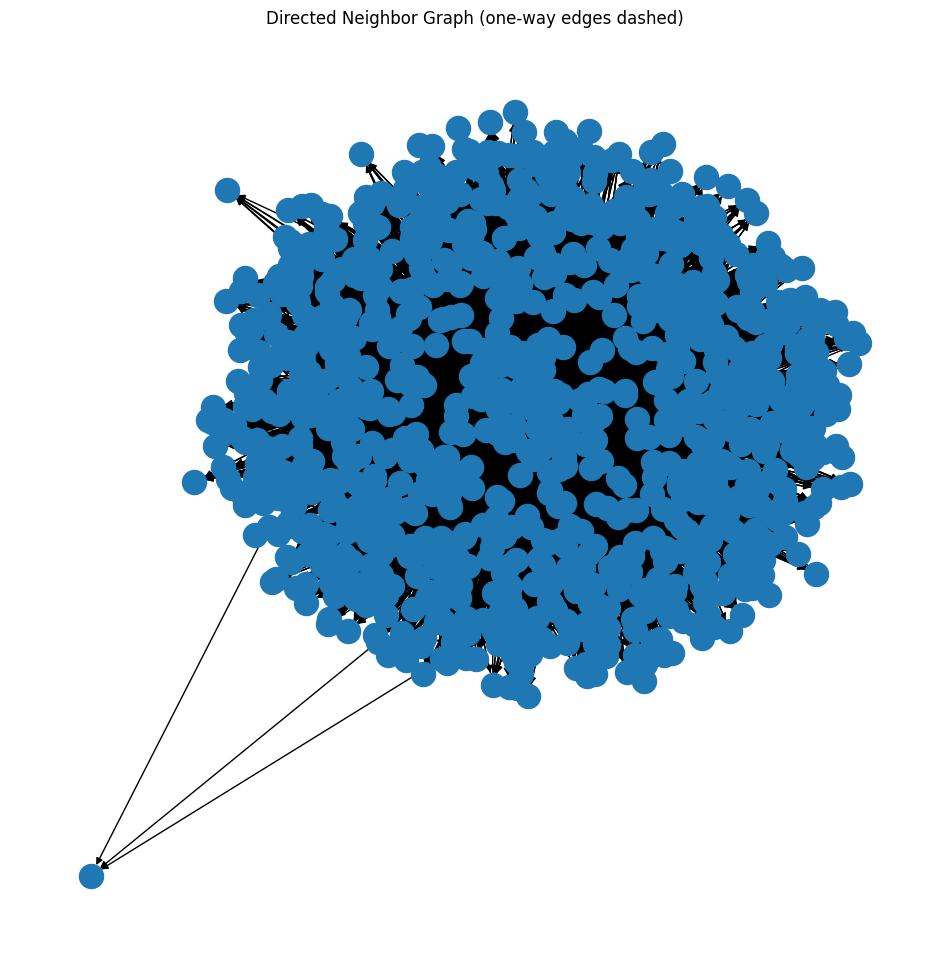

In [77]:
visualize_directed_graph(IG, with_labels=False)

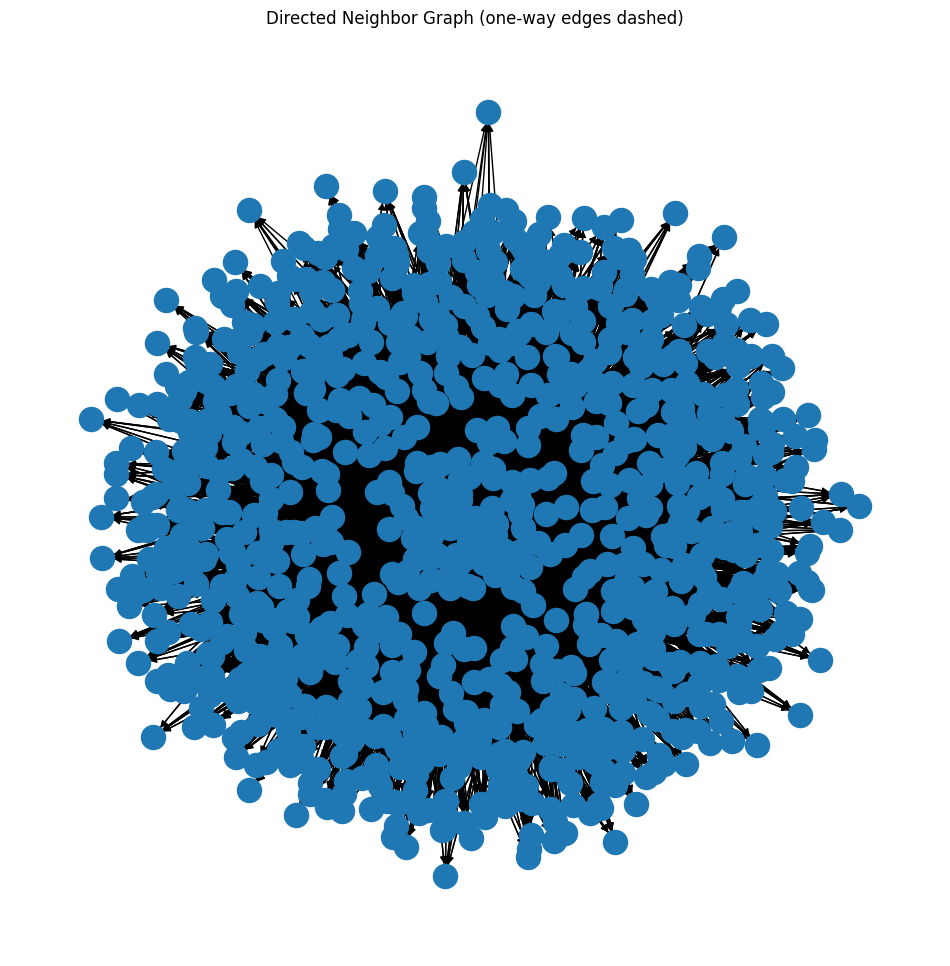

In [78]:
visualize_directed_graph(FG, with_labels=False)

In [ ]:
to_remove = [n for n in IG if (IG.in_degree(n) == 0) ^ (IG.out_degree(n) == 0)]
IG.remove_nodes_from(to_remove)
nx.is_strongly_connected(IG)

True

In [90]:
nx.diameter(IG)

4

In [97]:
IG.number_of_nodes()

992

In [91]:
to_remove = [n for n in FG if (FG.in_degree(n) == 0) ^ (FG.out_degree(n) == 0)]
FG.remove_nodes_from(to_remove)
nx.is_strongly_connected(FG)

True

In [92]:
nx.diameter(FG)

4

In [98]:
FG.number_of_nodes()

980

In [100]:
def axis_stats(a: np.ndarray):
    return {
        "row": {  # shape (25,)
            "min": a.min(axis=1),
            "max": a.max(axis=1),
            "mean": a.mean(axis=1),
            "median": np.median(a, axis=1),
        },
        "col": {  # shape (1000,)
            "min": a.min(axis=0),
            "max": a.max(axis=0),
            "mean": a.mean(axis=0),
            "median": np.median(a, axis=0),
        },
    }


In [102]:
stats = {}
for protocol in round_times.keys():
    stats[protocol] = axis_stats(round_times[protocol])

stats

{'expostMDAG': {'row': {'min': array([1.73114301e-01, 1.85516516e-01, 2.06324533e-01, 1.81359937e-01,
          1.89656091e-01, 1.85066357e-01, 2.40549732e-01, 1.61625177e-01,
          1.77826890e-01, 1.71508334e-01, 2.49018866e-01, 2.27166570e-01,
          2.20252479e-01, 2.38115521e-01, 2.36861257e-01, 2.38982787e-01,
          1.66037444e-01, 1.13389327e-01, 2.18377714e-01, 1.55561319e-01,
          2.11270688e-01, 9.27809060e-02, 1.50319288e-01, 2.19798510e-01,
          8.35600000e-05]),
   'max': array([1.73114301e-01, 1.85516516e-01, 2.06324533e-01, 1.81359937e-01,
          1.89656091e-01, 1.85066357e-01, 2.40549732e-01, 1.61625177e-01,
          1.77826890e-01, 1.71508334e-01, 2.49018866e-01, 2.27166570e-01,
          2.20252479e-01, 2.38115521e-01, 2.36861257e-01, 2.38982787e-01,
          1.66037444e-01, 1.13389327e-01, 2.18377714e-01, 1.55561319e-01,
          2.11270688e-01, 9.27809060e-02, 1.50319288e-01, 2.19798510e-01,
          8.35600000e-05]),
   'mean': array([1.7